Total CT slices: 281


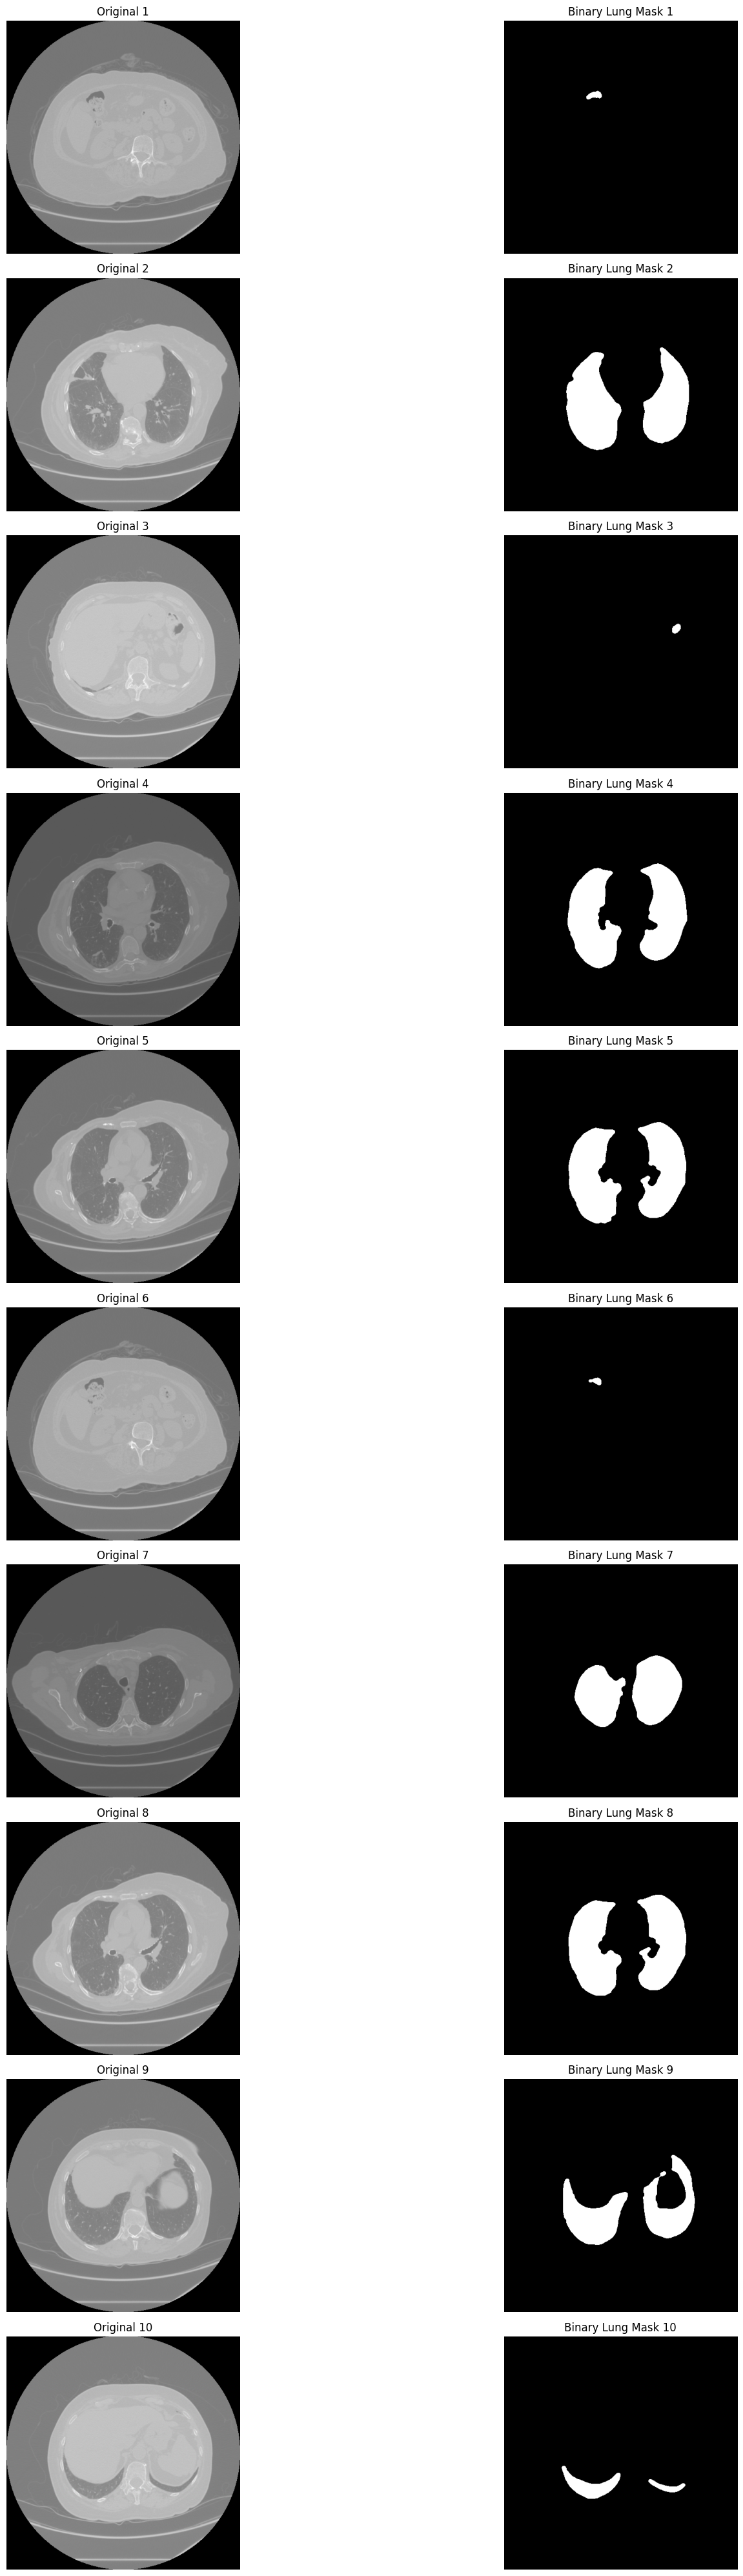

In [3]:
# ===============================
# IMPORTS
# ===============================
import os
import random
import pydicom
import numpy as np
import cv2
from concurrent.futures import ThreadPoolExecutor
import matplotlib.pyplot as plt

# -------------------------------
# --- Step 0: Kernel ---
# -------------------------------
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
kernel_big = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))

# -------------------------------
# --- Step 1: Utility Functions ---
# -------------------------------

def get_hu_image(ds):
    img = ds.pixel_array.astype(np.int16)
    slope = getattr(ds, "RescaleSlope", 1)
    intercept = getattr(ds, "RescaleIntercept", 0)
    return img * slope + intercept


def extract_body(hu_img, threshold=-500):
    mask = (hu_img > threshold).astype(np.uint8) * 255
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)
    if num_labels > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask = (labels == largest).astype(np.uint8) * 255

    return hu_img * (mask > 0), mask


def initial_lung_threshold(hu_img, lower=-1000, upper=-500):
    mask = ((hu_img >= lower) & (hu_img <= upper)).astype(np.uint8) * 255
    return cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)


def remove_border_connected(mask):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)
    new_mask = np.zeros_like(mask)

    for label in range(1, num_labels):
        x, y, w, h, _ = stats[label]
        if x > 0 and y > 0 and (x+w) < mask.shape[1] and (y+h) < mask.shape[0]:
            new_mask[labels == label] = 255

    return new_mask


def keep_two_largest(mask):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)

    if num_labels <= 2:
        return mask

    areas = [(i, stats[i, cv2.CC_STAT_AREA]) for i in range(1, num_labels)]
    areas = sorted(areas, key=lambda x: x[1], reverse=True)[:2]

    new_mask = np.zeros_like(mask)
    for label, _ in areas:
        new_mask[labels == label] = 255

    return new_mask


# -------------------------------
# --- Fill holes (IMPORTANT)
# -------------------------------
def fill_holes(mask):
    inv = cv2.bitwise_not(mask)

    h, w = mask.shape
    flood = inv.copy()
    flood_mask = np.zeros((h+2, w+2), np.uint8)

    cv2.floodFill(flood, flood_mask, (0,0), 255)

    flood_inv = cv2.bitwise_not(flood)
    return mask | flood_inv


# -------------------------------
# --- Final refinement
# -------------------------------
def refine_mask(mask):
    mask = cv2.medianBlur(mask, 5)

    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)

    mask = fill_holes(mask)

    # Extra smoothing for clean shape
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_big, iterations=2)

    # Smooth edges
    mask = cv2.GaussianBlur(mask, (5,5), 0)
    _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    return mask


# -------------------------------
# --- Step 2: Load CT paths ---
# -------------------------------
folder_root = "/home/server/Datasets/lidc/21-40/manifest-1771395775934/LIDC-IDRI/LIDC-IDRI-0039/01-01-2000-NA-NA-49300/3000517.000000-NA-01463"

ct_slices = []

for root, _, files in os.walk(folder_root):
    for file in files:
        if file.lower().endswith(".dcm"):
            try:
                ds = pydicom.dcmread(os.path.join(root, file), stop_before_pixels=True)
                if getattr(ds, "Modality", None) == "CT":
                    ct_slices.append((os.path.join(root, file), int(getattr(ds, "InstanceNumber", 0))))
            except:
                pass

ct_slices.sort(key=lambda x: x[1])
ct_paths = [p for p, _ in ct_slices]

print("Total CT slices:", len(ct_paths))


# -------------------------------
# --- Step 3: Process Slice ---
# -------------------------------
def process_slice(path):
    ds = pydicom.dcmread(path)
    hu_img = get_hu_image(ds)

    # Pipeline
    _, _ = extract_body(hu_img)
    lung_mask = initial_lung_threshold(hu_img)
    lung_mask = remove_border_connected(lung_mask)
    lung_mask = keep_two_largest(lung_mask)
    lung_mask = refine_mask(lung_mask)

    # ✅ FINAL: Binary mask
    binary_mask = (lung_mask > 0).astype(np.uint8) * 255

    # Display original
    orig = cv2.normalize(ds.pixel_array, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    return orig, binary_mask


# -------------------------------
# --- Step 4: Parallel Processing ---
# -------------------------------
sample_paths = random.sample(ct_paths, min(10, len(ct_paths)))

with ThreadPoolExecutor(max_workers=8) as executor:
    results = list(executor.map(process_slice, sample_paths))


# -------------------------------
# --- Step 5: Visualization ---
# -------------------------------
plt.figure(figsize=(20, 40))

for i, (orig, mask) in enumerate(results):
    plt.subplot(len(sample_paths), 2, i*2+1)
    plt.imshow(orig, cmap="gray")
    plt.title(f"Original {i+1}")
    plt.axis("off")

    plt.subplot(len(sample_paths), 2, i*2+2)
    plt.imshow(mask, cmap="gray")
    plt.title(f"Binary Lung Mask {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
import os
import pydicom
import numpy as np
import cv2
from tqdm import tqdm
from collections import defaultdict
import random

In [11]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))

def get_hu_image(ds):
    img = ds.pixel_array.astype(np.int16)
    slope = getattr(ds, "RescaleSlope", 1)
    intercept = getattr(ds, "RescaleIntercept", 0)
    return img * slope + intercept

def segment_lung(hu_img):
    # Threshold
    mask = (hu_img > -1000) & (hu_img < -500)
    mask = mask.astype(np.uint8) * 255

    # Morphology
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # Remove border components
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)
    clean = np.zeros_like(mask)

    for label in range(1, num_labels):
        x, y, w, h, area = stats[label]
        if x > 0 and y > 0 and (x+w) < mask.shape[1] and (y+h) < mask.shape[0]:
            clean[labels == label] = 255

    # Keep two largest
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(clean)
    areas = [(i, stats[i, cv2.CC_STAT_AREA]) for i in range(1, num_labels)]
    areas = sorted(areas, key=lambda x: x[1], reverse=True)[:2]

    final = np.zeros_like(mask)
    for i, _ in areas:
        final[labels == i] = 255

    return final

In [12]:
def find_ct_series(dataset_root):
    series_paths = []

    for root, dirs, files in os.walk(dataset_root):
        dcm_files = [f for f in files if f.endswith(".dcm")]

        # Heuristic: CT series has many slices
        if len(dcm_files) > 50:
            series_paths.append(root)

    return series_paths

In [13]:
def process_series(series_path, save_dir, patient_id):
    slices = []

    for file in os.listdir(series_path):
        if file.endswith(".dcm"):
            path = os.path.join(series_path, file)
            try:
                ds = pydicom.dcmread(path, stop_before_pixels=True)
                if getattr(ds, "Modality", None) == "CT":
                    slices.append((path, int(getattr(ds, "InstanceNumber", 0))))
            except:
                pass

    if len(slices) < 10:
        return

    # Sort slices
    slices.sort(key=lambda x: x[1])

    for i, (path, _) in enumerate(slices):
        ds = pydicom.dcmread(path)
        hu_img = get_hu_image(ds)

        mask = segment_lung(hu_img)

        # Normalize image for saving
        img = np.clip(hu_img, -1000, 400)
        img = ((img + 1000) / 1400 * 255).astype(np.uint8)

        filename = f"{patient_id}_{i:04d}.png"

        cv2.imwrite(os.path.join(save_dir, "images", filename), img)
        cv2.imwrite(os.path.join(save_dir, "masks", filename), mask)

In [14]:
dataset_root = "/home/server/Datasets/lidc"

output_root = "processed_dataset_final"

os.makedirs(output_root, exist_ok=True)

all_series = find_ct_series(dataset_root)

print("Total CT series found:", len(all_series))


Total CT series found: 1018


In [15]:
from collections import defaultdict
import random

patient_map = defaultdict(list)

for path in all_series:
    parts = path.split("/")
    patient_id = None   # important reset

    for p in parts:
        if p.startswith("LIDC-IDRI-"):
            patient_id = p
            break

    if patient_id is not None:
        patient_map[patient_id].append(path)

print("Total patients found:", len(patient_map))


patients = list(patient_map.keys())
random.shuffle(patients)

n = len(patients)

train_p = patients[:int(0.7*n)]
val_p   = patients[int(0.7*n):int(0.85*n)]
test_p  = patients[int(0.85*n):]

print("Train:", len(train_p))
print("Val:", len(val_p))
print("Test:", len(test_p))

Total patients found: 1010
Train: 707
Val: 151
Test: 152


In [16]:
def make_dirs(base):
    os.makedirs(os.path.join(base, "images"), exist_ok=True)
    os.makedirs(os.path.join(base, "masks"), exist_ok=True)

make_dirs(os.path.join(output_root, "train"))
make_dirs(os.path.join(output_root, "val"))
make_dirs(os.path.join(output_root, "test"))

In [ ]:
from concurrent.futures import ThreadPoolExecutor

def process_patient(patient):
    for series_path in patient_map[patient]:
        process_series(series_path, save_dir, patient)

for split, patient_list in [("train", train_p), ("val", val_p), ("test", test_p)]:
    print(f"Processing {split}...")

    save_dir = os.path.join(output_root, split)

    with ThreadPoolExecutor(max_workers=8) as executor:
        list(tqdm(executor.map(process_patient, patient_list), total=len(patient_list)))

Processing train...


  0%|          | 3/707 [00:46<2:46:45, 14.21s/it]

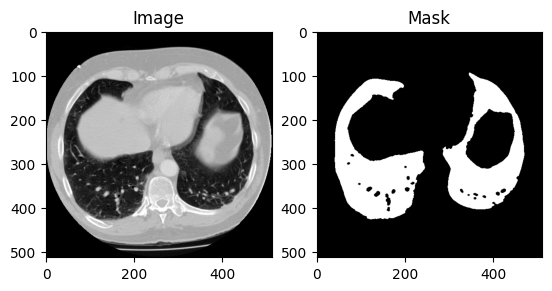

In [4]:
import cv2
import matplotlib.pyplot as plt
import os

files = os.listdir("processed_dataset/train/images")

file = files[1]  # pick first file

img = cv2.imread(os.path.join("processed_dataset/train/images", file), 0)
mask = cv2.imread(os.path.join("processed_dataset/train/masks", file), 0)

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask, cmap='gray')
plt.title("Mask")

plt.show()

In [3]:
!pip cache purge

Files removed: 490


In [4]:
!rm -rf ~/.cache/pip

In [9]:
!pip uninstall numpy -y
!pip install numpy==1.26.4

Found existing installation: numpy 2.1.3
Uninstalling numpy-2.1.3:
  Successfully uninstalled numpy-2.1.3
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 48.3 MB/s eta 0:00:00a 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


In [1]:
!pip uninstall -y numpy tensorflow keras
!pip cache purge

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
Found existing installation: keras 3.13.2
Uninstalling keras-3.13.2:
  Successfully uninstalled keras-3.13.2
Files removed: 48


In [3]:
!pip install numpy==1.26.4
!pip install tensorflow==2.19.0

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 11.1 MB/s eta 0:00:0000:0100:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 7.0 MB/s eta 0:00:0000:0100:03m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 13.0 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [4]:
import numpy as np
import tensorflow as tf

print("NumPy:", np.__version__)
print("TF:", tf.__version__)

2026-04-01 14:31:39.907248: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-01 14:31:39.930014: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775034099.956555 1474274 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775034099.965040 1474274 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775034099.984963 1474274 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

NumPy: 1.26.4
TF: 2.19.0


Total CT slices: 281


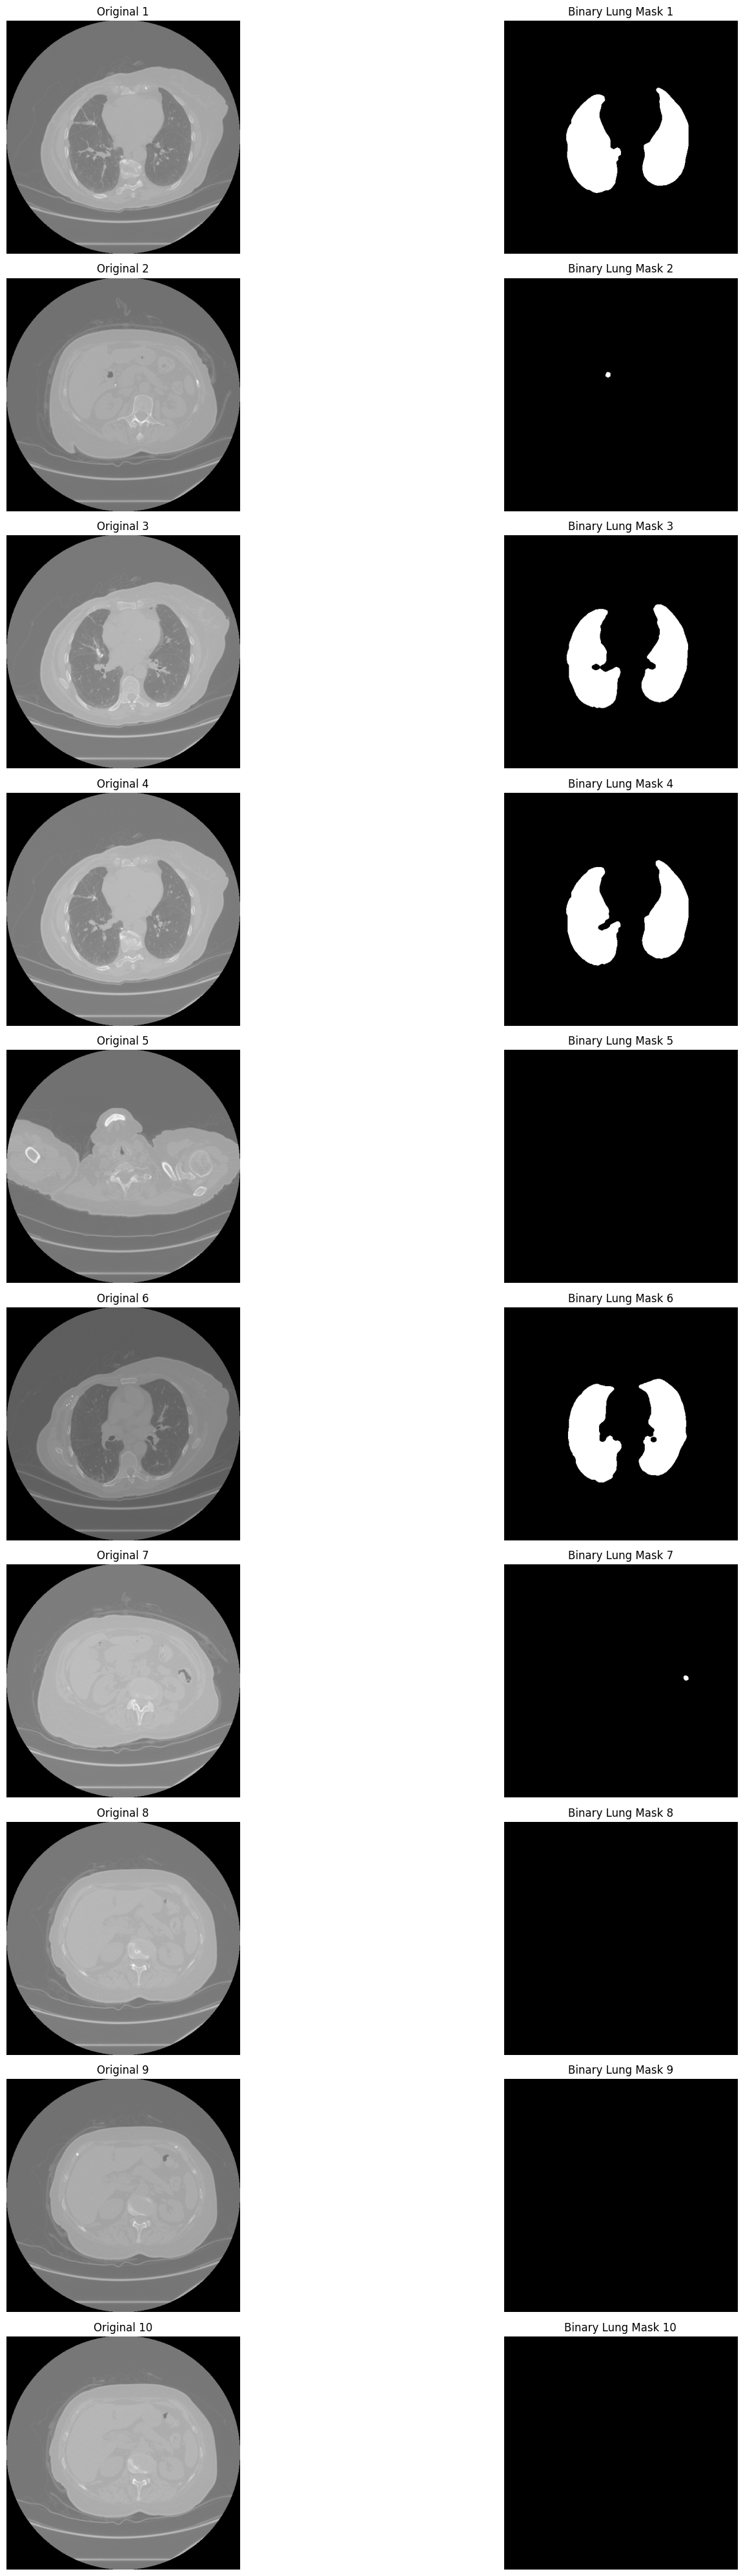

In [2]:
# ===============================
# 🔴 FORCE CPU (NO GPU ERRORS)
# ===============================
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# ===============================
# IMPORTS
# ===============================
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.utils import Sequence
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

IMG_SIZE = 256
BATCH_SIZE = 8

# ===============================
# DATA GENERATOR (FIXED)
# ===============================
class DataGenerator(Sequence):
    def __init__(self, img_dir, mask_dir, batch_size=8):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.batch_size = batch_size

        self.files = os.listdir(img_dir)[:500]   # 🔥 LIMIT for speed

    def __len__(self):
        return len(self.files) // self.batch_size

    def __getitem__(self, idx):
        batch_files = self.files[idx*self.batch_size:(idx+1)*self.batch_size]

        imgs = np.zeros((len(batch_files), IMG_SIZE, IMG_SIZE, 1), dtype=np.float32)
        masks = np.zeros((len(batch_files), IMG_SIZE, IMG_SIZE, 1), dtype=np.float32)

        for i, f in enumerate(batch_files):
            img_path = os.path.join(self.img_dir, f)
            mask_path = os.path.join(self.mask_dir, f)

            img = cv2.imread(img_path, 0)
            mask = cv2.imread(mask_path, 0)

            if img is None or mask is None:
                continue

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

            imgs[i, :, :, 0] = img / 255.0
            masks[i, :, :, 0] = mask / 255.0

        return imgs, masks

# ===============================
# LOAD DATA
# ===============================
train_gen = DataGenerator(
    "processed_dataset/train/images",
    "processed_dataset/train/masks",
    batch_size=BATCH_SIZE
)

val_gen = DataGenerator(
    "processed_dataset/val/images",
    "processed_dataset/val/masks",
    batch_size=BATCH_SIZE
)

# ===============================
# LIGHTWEIGHT U-NET
# ===============================
def build_unet():
    inputs = layers.Input((256,256,1))

    c1 = layers.Conv2D(16,3,activation='relu',padding='same')(inputs)
    c1 = layers.Conv2D(16,3,activation='relu',padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(32,3,activation='relu',padding='same')(p1)
    c2 = layers.Conv2D(32,3,activation='relu',padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    b = layers.Conv2D(64,3,activation='relu',padding='same')(p2)

    u1 = layers.UpSampling2D()(b)
    u1 = layers.concatenate([u1, c2])
    c3 = layers.Conv2D(32,3,activation='relu',padding='same')(u1)

    u2 = layers.UpSampling2D()(c3)
    u2 = layers.concatenate([u2, c1])
    c4 = layers.Conv2D(16,3,activation='relu',padding='same')(u2)

    outputs = layers.Conv2D(1,1,activation='sigmoid')(c4)

    return models.Model(inputs, outputs)

# ===============================
# LOSS
# ===============================
def dice_loss(y_true, y_pred):
    smooth = 1e-6
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return 0.5 * bce + 0.5 * dice_loss(y_true, y_pred)

# ===============================
# CALLBACKS
# ===============================
checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_loss',
    save_best_only=True
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# ===============================
# TRAIN (FORCE CPU)
# ===============================
with tf.device('/CPU:0'):

    model = build_unet()

    model.compile(
        optimizer='adam',
        loss=combined_loss,
        metrics=['accuracy']
    )

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=2,   # 🔥 FAST
        callbacks=[checkpoint, early_stop]
    )


def keep_largest_two_regions(mask):
    mask = mask.astype(np.uint8)

    # Find connected components
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    if num_labels <= 2:
        return mask  # already small

    # Get areas (skip background label 0)
    areas = stats[1:, cv2.CC_STAT_AREA]

    # Get indices of two largest components
    largest_idxs = np.argsort(areas)[-2:] + 1

    # Create clean mask
    clean_mask = np.zeros_like(mask)

    for idx in largest_idxs:
        clean_mask[labels == idx] = 1

    return clean_mask

# ===============================
# VISUALIZE RESULTS
# ===============================
imgs, masks = val_gen[0]
# After prediction
preds = model.predict(imgs)
preds_bin = (preds > 0.5).astype(np.uint8)

# 🔥 Keep only 2 largest regions (lungs)
clean_preds = np.zeros_like(preds_bin)

for i in range(len(preds_bin)):
    clean_preds[i, :, :, 0] = keep_largest_two_regions(preds_bin[i, :, :, 0])

plt.figure(figsize=(12,8))

for i in range(3):
    plt.subplot(3,3,i*3+1)
    plt.imshow(imgs[i].squeeze(), cmap='gray')
    plt.title("Image")

    plt.subplot(3,3,i*3+2)
    plt.imshow(masks[i].squeeze(), cmap='gray')
    plt.title("Mask")

    plt.subplot(3,3,i*3+3)
    plt.imshow(clean_preds[i].squeeze(), cmap='gray')
    plt.title("Lung Only")

plt.tight_layout()
plt.show()

# ===============================
# SAVE MODEL
# ===============================
model.save("lung_segmentation_model.h5")